# Pick and Place for the myCobot 280 Labs
## Lab 8: Vision-Driven Sorting with Suction Gripper

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab brings together the full pick-and-place pipeline: a vision node detects coloured cubes with a camera, estimates their 3D position in the robot base frame, and publishes the result on a ROS 2 topic. A motion node subscribes to these detections and executes an autonomous sorting routine using a vacuum gripper. You will work through each stage of this pipeline — from workspace geometry and GPIO pump control, through Cartesian motion commands, to the complete pick-and-place state machine with colour-based bin sorting.

**Important — real-robot safety:** Every cell that sends a motion command is guarded by an `enable_motion = False` flag. You must deliberately set it to `True` before executing. Never run the robot without checking the workspace is clear.

**Offline completion:** hardware access defaults to disabled, so calculations and selection examples run on the PC without serial/GPIO packages. For real execution over Ethernet, run the kernel on `cobot@129.217.130.11`, restore SSH connectivity, and confirm the local UART and calibrated workspace. Do not run a competing serial controller. Timed waits do not confirm motion completion.

In [1]:
import os
import time
import numpy as np
from IPython import get_ipython
import importlib.util
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "widget" if importlib.util.find_spec("ipympl") else "inline")
import matplotlib.pyplot as plt

# Offline calculations run by default. Enable only on the robot computer.
enable_hardware = True
enable_motion = False
stop_flag = {"stop": False}

def require_motion(mc):
    if not enable_hardware or not enable_motion or mc is None:
        raise RuntimeError("Enable hardware and motion explicitly on the robot before commanding it.")

def check_stop():
    if stop_flag["stop"]:
        pump_off()
        return True
    return False

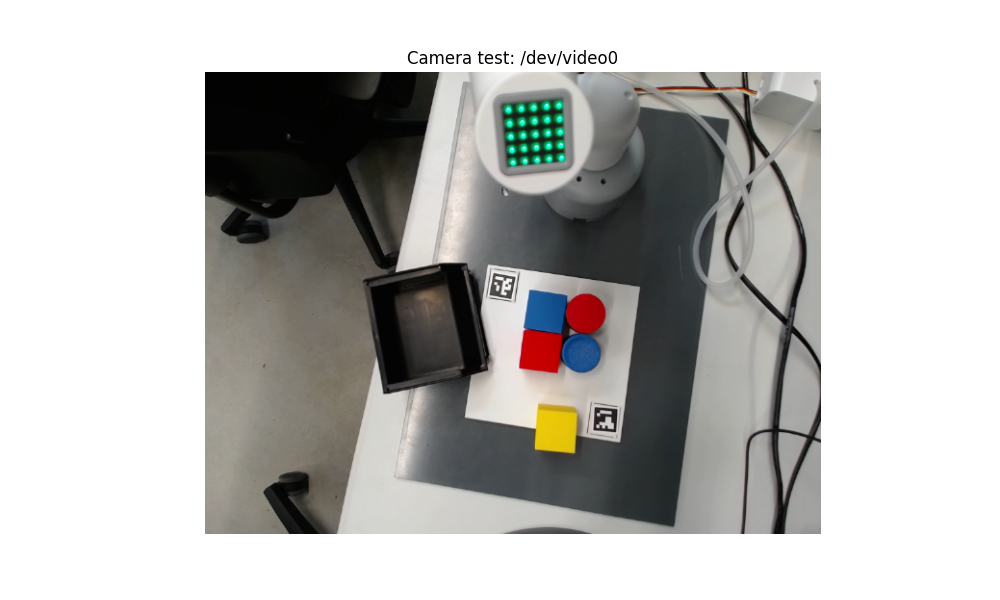

In [2]:
import cv2
import matplotlib.pyplot as plt

camera_device = "/dev/video0"  # Change only this after checking v4l2-ctl

cap = cv2.VideoCapture(camera_device, cv2.CAP_V4L2)
if not cap.isOpened():
    raise RuntimeError(f"Could not open {camera_device}")

ok, frame = cap.read()
cap.release()

if not ok or frame is None:
    raise RuntimeError("Camera opened but no frame was received")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title(f"Camera test: {camera_device}")
plt.show()

## System Overview

The pick-and-place application consists of three ROS 2 packages:

- **`vision`** — camera-based object detection and pose estimation (YOLO + `cv2.solvePnP`)
- **`mycobot_msgs`** — custom message definitions (`DetectedObject`, `JointVelocity`)
- **`mycobot_motion_v1`** — motion execution, target selection, and vacuum gripper control

The vision node publishes detected object positions (in metres, robot base frame) on the topic `/detected_objects`. The motion node subscribes, filters by workspace bounds, buffers detections over a short time window, selects a target by stack height and colour priority, and executes a full pick-and-place cycle using Cartesian commands and the vacuum gripper.

In this lab you will reconstruct each component of the motion node step by step.

## Setup and Robot Connection

### 1. Connect to the myCobot 280

The pick-and-place codebase controls the robot directly through the `pymycobot` library (not through the ROS 2 controller). Create the connection object using the correct serial device and baud rate from the codebase.

In [3]:
from pathlib import Path

# Reference: src/mycobot_motion_v1/mycobot_motion_v1/motion_node.py
serial_port = os.environ.get("MYCOBOT_PORT", "/dev/serial0")
baud_rate = 1_000_000
if "mc" in globals() and mc is not None:
    mc.close()
mc = None
if enable_hardware:
    from pymycobot.mycobot import MyCobot
    if not Path(serial_port).exists():
        raise FileNotFoundError(f"{serial_port} is missing. Run on the robot and confirm its UART path.")
    mc = MyCobot(serial_port, baud_rate)
    time.sleep(0.2)
    print("Serial connection opened:", serial_port, "at", baud_rate)
else:
    print("Offline mode: serial connection not opened.")

FileNotFoundError: /dev/serial0 is missing. Run on the robot and confirm its UART path.

In [4]:
import socket
print("Notebook is running on:", socket.gethostname())

Notebook is running on: CoRobot5


## Workspace Geometry and Constants

### 2. Define the workspace constants

The motion node uses a set of constants to define the workspace geometry, motion timing, and tool offset. Fill in each value from `motion_node.py`.

In [ ]:
# Tool geometry
NOZZLE_LENGTH_MM = 68.0   # suction nozzle length (TCP offset)
HOVER_MARGIN     = 70.0   # clearance above pick height

# Motion timing
MOVE_SPEED   = 50
MOTION_SLEEP = 1.5   # seconds between moves

# Drop height
DROP_Z_MM = 60.0   # Z height for the drop position above the table

print(f'Nozzle: {NOZZLE_LENGTH_MM} mm, Hover margin: {HOVER_MARGIN} mm')
print(f'Speed: {MOVE_SPEED}, Sleep: {MOTION_SLEEP} s, Drop Z: {DROP_Z_MM} mm')

### 3. Define the home and intermediate positions

The robot uses a two-step return-to-home sequence: it first moves to an intermediate waypoint (to avoid collisions with bins or cubes), then to the home position. Both are Cartesian poses `[x, y, z, rx, ry, rz]` in mm and degrees. Fill in the values from the codebase.

In [ ]:
HOME_COORDS  = [51.3, -63.3, 412.67, -91.75, -0.63, -89.98]
INTER_COORDS = [156.4, -17.2, 247.8, 179.27, 0.21, -1.4]

HOME_SPEED = 40
HOME_DELAY = 4.0   # seconds to wait after each home move

print('Home:', HOME_COORDS)
print('Intermediate:', INTER_COORDS)

### 4. Define workspace bounds

The motion node rejects any detection whose position (converted to mm) falls outside a rectangular region in the XY plane. This prevents the robot from attempting unreachable or unsafe motions. Fill in the limits from the codebase.

In [ ]:
WORKSPACE_X_MIN = 75.0    # mm
WORKSPACE_X_MAX = 225.0   # mm
WORKSPACE_Y_MIN = -75.0   # mm
WORKSPACE_Y_MAX = 75.0    # mm

print(f'X: [{WORKSPACE_X_MIN}, {WORKSPACE_X_MAX}] mm')
print(f'Y: [{WORKSPACE_Y_MIN}, {WORKSPACE_Y_MAX}] mm')

### 5. Define colour-specific bin coordinates

Each detected colour maps to a bin location where the object should be dropped. The bins are defined by `[x, y]` in mm — the Z height for dropping is computed separately. Fill in the coordinates from the codebase.

In [ ]:
BIN_COORDS = {
    "red":    [132.2, -147.9],
    "yellow": [245.8, -150.1],
    "green":  [115.8,  177.3],
    "blue":   [ -6.9,  173.2],
    "cyan":   [ -6.9,  173.2],
}

for color, coords in BIN_COORDS.items():
    print(f'{color:8s} → x={coords[0]:7.1f}, y={coords[1]:7.1f} mm')

## Vacuum Gripper Control via GPIO

The suction gripper is controlled through two GPIO pins on the Raspberry Pi (BCM numbering):

- **Pin 20:** vacuum motor (active-low — `0` = suction ON)
- **Pin 21:** release valve (active-low — `0` = valve closed)

Setting both pins LOW activates suction. Setting both HIGH deactivates the pump and opens the release valve.

### 6. Set up GPIO pins

Configure both pins as outputs and set them HIGH (off) as the initial safe state.

In [ ]:
GPIO = None
if enable_hardware:
    import RPi.GPIO as GPIO
    GPIO.setwarnings(False)
    GPIO.setmode(GPIO.BCM)
    GPIO.setup(20, GPIO.OUT, initial=GPIO.HIGH)
    GPIO.setup(21, GPIO.OUT, initial=GPIO.HIGH)
    print("GPIO pins 20 and 21 HIGH (pump off)")
else:
    print("Offline mode: GPIO not initialized.")

### 7. Implement `pump_on` and `pump_off`

Write two functions that activate and deactivate the suction pump. The `pump_off` function must first turn off the vacuum motor, wait briefly, then open the release valve and wait for the object to detach.

**Question:** Why does `pump_off` use a 2.0 s delay after opening the release valve?

**Answer:** the 2-second delay allows the vacuum to dissipate and the object to detach before retreat. It is a fixed delay, not a sensor-confirmed release.

In [ ]:
def pump_on():
    """Activate suction using the reference wiring."""
    if not enable_hardware or GPIO is None:
        raise RuntimeError("Initialize GPIO on the robot first.")
    GPIO.output(20, GPIO.LOW)
    GPIO.output(21, GPIO.LOW)
    print("Pump ON")

def pump_off():
    """Stop the motor, then open the valve and allow pressure to equalize."""
    if not enable_hardware or GPIO is None:
        raise RuntimeError("Initialize GPIO on the robot first.")
    GPIO.output(20, GPIO.HIGH)
    time.sleep(0.3)
    GPIO.output(21, GPIO.HIGH)
    time.sleep(2.0)
    print("Pump OFF")

### 8. Test the pump

Activate the pump for a few seconds, then deactivate it. Hold a small object near the nozzle to verify suction.

In [ ]:
enable_pump_test = False   # Set True to test

if enable_pump_test:
    pump_on()
    time.sleep(3.0)
    pump_off()
    print('Pump test complete')
else:
    print('Pump test disabled. Set enable_pump_test = True to run.')

## Cartesian Motion Fundamentals

The pick-and-place system controls the robot in Cartesian coordinates using `mc.send_coords([x, y, z, rx, ry, rz], speed)`, where positions are in mm and orientations in degrees.

Throughout the pick-and-place sequence, the end-effector orientation is fixed at `[180, 0, 0]` — pointing straight down.

### 9. Send the robot to the home position

Implement the two-step home sequence: first move to `INTER_COORDS`, wait, then move to `HOME_COORDS`. The third argument `0` in `send_coords` sets the movement mode.

In [ ]:
def go_home(mc):
    """Command intermediate and home waypoints; timed waits are not feedback."""
    require_motion(mc)
    for pose in [INTER_COORDS, HOME_COORDS]:
        if check_stop():
            return False
        mc.send_coords(pose, HOME_SPEED, 0)
        time.sleep(HOME_DELAY)
    print("Home sequence commands completed; verify actual position.")
    return True

enable_motion = False
if enable_motion:
    go_home(mc)
else:
    print("Motion disabled.")

### 10. Compute pick, hover, and drop heights

The motion node computes end-effector heights dynamically from the detected object position. Three heights matter:

- **Pick height** — nozzle tip touches the object: `z_pick = z_obj + NOZZLE_LENGTH_MM`
- **Hover height** — safe clearance above the object: `z_hover = z_pick + HOVER_MARGIN`
- **Drop height** — fixed release height above the bin: `z_drop = DROP_Z_MM + NOZZLE_LENGTH_MM`

Given a simulated detection at `z_obj = 40.0 mm`, compute all three heights.

In [ ]:
# Simulated object height (mm)
z_obj = 40.0

z_pick  = z_obj + NOZZLE_LENGTH_MM   # Compute the end-effector pick height
z_hover = z_pick + HOVER_MARGIN   # Compute a safe hover height above the pick point
z_drop  = DROP_Z_MM + NOZZLE_LENGTH_MM   # Compute the end-effector drop height

print(f'Object Z:  {z_obj:.1f} mm')
print(f'Pick Z:    {z_pick:.1f} mm   (nozzle tip at object surface)')
print(f'Hover Z:   {z_hover:.1f} mm  (safe clearance above object)')
print(f'Drop Z:    {z_drop:.1f} mm   (release height above bin)')

### 11. Send a single Cartesian move

Send the robot to a position within the known workspace. Use the downward-pointing orientation `[180, 0, 0]` and the standard `MOVE_SPEED`. Always call `time.sleep(MOTION_SLEEP)` after `send_coords` to allow the motion to complete.

**Note:** The target below is chosen to be within the safe workspace and at a safe height.

In [ ]:
# A safe test target within the workspace
test_target = [150.0, 0.0, 250.0, 180, 0, 0]

enable_motion = False   # Set True to move the robot

if enable_motion:
    require_motion(mc)
    mc.send_coords(test_target, MOVE_SPEED)
    time.sleep(MOTION_SLEEP)
    print('Moved to test target:', test_target)
    
    # Return home
    go_home(mc)
else:
    print('Motion disabled. Set enable_motion = True to move the robot.')

## Pick-and-Place State Machine

The core of the motion node is the `execute_pick_and_place` function, which runs the following eight-step sequence:

1. **Hover** — move above the object at hover height
2. **Pump ON** — activate the vacuum
3. **Descend** — lower to pick height
4. **Lift** — raise back to hover height (object attached)
5. **Bin hover** — move laterally to the colour-specific bin at hover height
6. **Drop descend** — lower to the drop height above the bin
7. **Pump OFF** — release the object
8. **Retreat and home** — lift from bin, return home via intermediate waypoint

### 12. Implement the pick-and-place sequence

Complete the function below. Use the simulated detection values provided. The wrist orientation for all moves is `[180, 0, 0]`.

In [ ]:
def execute_pick_and_place(mc, obj_x, obj_y, obj_z, color):
    """Object coordinates in mm; return False if rejected or stopped."""
    require_motion(mc)
    if (not np.all(np.isfinite([obj_x, obj_y, obj_z])) or obj_z < 0
            or not WORKSPACE_X_MIN <= obj_x <= WORKSPACE_X_MAX
            or not WORKSPACE_Y_MIN <= obj_y <= WORKSPACE_Y_MAX
            or color not in BIN_COORDS):
        return False
    pick_ee_z = obj_z + NOZZLE_LENGTH_MM
    hover_ee_z = pick_ee_z + HOVER_MARGIN
    drop_ee_z = DROP_Z_MM + NOZZLE_LENGTH_MM
    if hover_ee_z <= drop_ee_z:
        raise ValueError("Hover must be above the drop pose; check the detected height.")
    bx, by = BIN_COORDS[color]

    def move(x, y, z):
        if check_stop():
            return False
        mc.send_coords([x, y, z, 180, 0, 0], MOVE_SPEED)
        time.sleep(MOTION_SLEEP)
        return True

    if not move(obj_x, obj_y, hover_ee_z): return False
    if check_stop(): return False
    pump_on()
    if not move(obj_x, obj_y, pick_ee_z): return False
    if not move(obj_x, obj_y, hover_ee_z): return False
    if not move(bx, by, hover_ee_z): return False
    if not move(bx, by, drop_ee_z): return False
    if check_stop(): return False
    pump_off()
    if not move(bx, by, hover_ee_z): return False
    if not go_home(mc): return False
    print(f"Sequence commands completed for {color}; verify pickup and release.")
    return True

### 13. Test the pick-and-place sequence

Use a simulated detection within the workspace to test your implementation. Place a cube at approximately the position below before running.

**Safety:** Verify the target coordinates are within the workspace bounds before enabling motion.

In [ ]:
# Simulated detection (values in mm, as if already converted from metres)
test_obj_x = 150.0
test_obj_y = 0.0
test_obj_z = 40.0
test_color = 'red'

# Verify workspace bounds
in_bounds = (WORKSPACE_X_MIN <= test_obj_x <= WORKSPACE_X_MAX and
             WORKSPACE_Y_MIN <= test_obj_y <= WORKSPACE_Y_MAX)
print(f'Target in workspace: {in_bounds}')

enable_motion = False   # Set True to move the robot

if enable_motion and in_bounds:
    execute_pick_and_place(mc, test_obj_x, test_obj_y, test_obj_z, test_color)
else:
    print('Motion disabled or target out of bounds.')

## Colour-Based Bin Sorting and Priority Logic

### 14. Implement colour priority selection

When multiple cubes are detected simultaneously, the motion node selects a target using a priority rule. Detections are first sorted by descending Z (taller stacks first), then by colour priority (lower number = higher priority).

Fill in the `COLOR_PRIORITY` dictionary and implement the selection function. The function should filter detections that have a known colour and lie inside the workspace, then sort by the priority rule.

In [ ]:
COLOR_PRIORITY = {
    "red":    0,
    "yellow": 1,
    "green":  2,
    "cyan":   3,
}

def is_inside_workspace(x_m, y_m):
    """Check if a detection (in metres) is inside the workspace."""
    x_mm = x_m * 1000.0
    y_mm = y_m * 1000.0
    return (WORKSPACE_X_MIN <= x_mm <= WORKSPACE_X_MAX and
            WORKSPACE_Y_MIN <= y_mm <= WORKSPACE_Y_MAX)   # Apply the configured workspace limits

def choose_target(detections):
    """
    Select the highest-priority target from a list of detections.
    
    Each detection is a dict: {'x': float, 'y': float, 'z': float, 'color': str}
    where x, y, z are in metres.
    
    Returns the selected detection dict, or None.
    """
    valid = [
        d for d in detections
        if d['color'] in COLOR_PRIORITY and np.all(np.isfinite([d['x'], d['y'], d['z']])) and d['z'] >= 0 and is_inside_workspace(d['x'], d['y'])
    ]   # Keep only detections with a supported priority and valid workspace position
    
    if not valid:
        return None
    
    # Sort: highest z first (descending), then colour priority (ascending)
    valid.sort(key=lambda d: (-d['z'], COLOR_PRIORITY[d['color']]))   # Sort by stack height first, then colour priority
    return valid[0]

### 15. Test the priority selection

Create a buffer of simulated detections and verify that the selection logic picks the correct target.

In [ ]:
# Simulated detection buffer (values in metres)
detections = [
    {'x': 0.150, 'y': 0.000, 'z': 0.040, 'color': 'green'},
    {'x': 0.120, 'y': 0.030, 'z': 0.040, 'color': 'red'},
    {'x': 0.200, 'y': -0.050, 'z': 0.080, 'color': 'yellow'},   # stacked — higher z
    {'x': 0.300, 'y': 0.000, 'z': 0.040, 'color': 'cyan'},      # outside workspace
]

target = choose_target(detections)

if target is not None:
    print(f'Selected: {target["color"]} at '
          f'x={target["x"]:.3f}, y={target["y"]:.3f}, z={target["z"]:.3f} m')
else:
    print('No valid target found')

# Expected: yellow at z=0.080 (highest stack), since it has the highest z
# If two had the same z, red (priority 0) would be chosen over green (priority 2)

## Workspace Validation

### 16. Validate workspace bounds checking

Test your `is_inside_workspace` function with several positions — some inside, some outside the workspace. Remember that the function receives coordinates in **metres** (as published by the vision node) and must convert to mm internally for the comparison.

In [ ]:
test_positions = [
    (0.150, 0.000, 'centre of workspace'),
    (0.075, -0.075, 'corner — just inside'),
    (0.050, 0.000, 'too far left (x too small)'),
    (0.250, 0.000, 'too far right (x too large)'),
    (0.150, 0.100, 'too far forward (y too large)'),
]

for x_m, y_m, label in test_positions:
    result = is_inside_workspace(x_m, y_m)
    status = 'INSIDE' if result else 'OUTSIDE'
    print(f'  ({x_m:.3f}, {y_m:.3f}) m → {x_m*1000:.0f}, {y_m*1000:.0f} mm → {status:7s}  ({label})')

## Camera-to-Robot Base Coordinate Transform

The vision node estimates the object pose in the camera coordinate frame using `cv2.solvePnP`. To command the robot, this must be transformed into the robot base frame using a fixed 4×4 homogeneous transformation matrix.

The rotation `R_base_cam` maps:
- camera x-axis → robot base y-axis
- camera y-axis → robot base x-axis
- camera z-axis → negative robot base z-axis

The translation `t_base_cam = [0.170, 0.0, 0.39]` (metres) describes the camera origin in the robot base frame.

### 17. Construct the camera-to-base transformation matrix

Build the 4×4 homogeneous matrix `T_base_cam` from the rotation and translation.

In [ ]:
R_base_cam = np.array([[0, 1, 0], [1, 0, 0], [0, 0, -1]], dtype=float)
t_base_cam = np.array([0.170, 0.0, 0.39])
T_base_cam = np.eye(4)
T_base_cam[:3, :3] = R_base_cam
T_base_cam[:3, 3] = t_base_cam
print("T_base_cam:\n", T_base_cam)

### 18. Apply the coordinate transform to a simulated detection

Given a simulated object pose in the camera frame (rotation from `solvePnP` and corrected translation), compute the object position in the robot base frame.

For this exercise, assume the solvePnP rotation is the identity (object aligned with camera axes) and the corrected translation is `[tx, ty, Z_abs] = [0.02, -0.01, 0.36]` metres.

In [ ]:
# Simulated camera-frame object pose
R_cam_obj = np.eye(3, dtype=np.float32)   # identity for simplicity
t_cam_obj = np.array([0.02, -0.01, 0.36], dtype=np.float32)

T_cam_obj = np.eye(4, dtype=np.float32)
T_cam_obj[:3, :3] = R_cam_obj
T_cam_obj[:3, 3]  = t_cam_obj

# Transform to base frame
T_base_obj = T_base_cam @ T_cam_obj   # Transform the object pose from camera frame to base frame

object_pos_base = T_base_obj[:3, 3]
print(f'Object position in base frame: x={object_pos_base[0]:.4f}, '
      f'y={object_pos_base[1]:.4f}, z={object_pos_base[2]:.4f} m')

### 19. Z-scale calibration

The raw depth estimate from `solvePnP` is not accurate enough for reliable manipulation. The vision node calibrates the depth using a scale factor computed from a known reference:

$$f_{\text{scale}} = \frac{Z_{\text{one}}}{z_{\text{ref}}}$$

where $Z_{\text{one}} = 0.36$ m is the reference camera-frame depth for one cube on the table and $z_{\text{ref}}$ is the average raw PnP depth from five calibration samples. Each subsequent measurement is corrected by $z_{\text{corrected}} = z_{\text{raw}} \cdot f_{\text{scale}}$.

Compute the scale factor and corrected depth for the example values below.

In [ ]:
Z_ONE_CUBE = 0.36       # reference camera depth for one cube (metres)
CUBE_HEIGHT = 0.04      # height of one cube (metres)

# Example calibration data
z_ref_raw = 0.385       # average raw PnP depth from 5 samples

f_scale = Z_ONE_CUBE / z_ref_raw           # Compute the depth-correction scale factor

# A new raw measurement
z_raw_new = 0.370
z_corrected = z_raw_new * f_scale       # Apply the calibration scale to the raw depth

print(f'Scale factor:    {f_scale:.4f}')
print(f'Raw depth:       {z_raw_new:.4f} m')
print(f'Corrected depth: {z_corrected:.4f} m')

### 20. Estimate stack level from corrected depth

A higher stack of cubes appears closer to the camera, producing a smaller corrected depth value. The stack level is estimated from the difference between the corrected depth and the single-cube reference:

$$\Delta z = z_{\text{corrected}} - Z_{\text{one}}, \qquad \ell = \max\bigl(0,\; \text{round}(-\Delta z \,/\, h_{\text{cube}})\bigr)$$

Compute the level for two corrected depth values: 0.36 m (one cube) and 0.32 m (two cubes stacked).

`level=0` denotes one cube. `Z_absolute` in the reference code is quantized **camera depth**, not base-frame height. With the supplied transform, base height is `0.39 - Z_absolute`; the examples yield 0.03, 0.07 and 0.11 m. The supplied calibration is illustrative and must be checked on the actual workspace.

In [ ]:
def compute_stack_level(z_corrected):
    if not np.isfinite(z_corrected) or z_corrected <= 0:
        raise ValueError("Corrected camera depth must be finite and positive.")
    delta_z = z_corrected - Z_ONE_CUBE
    level = max(0, int(round(-delta_z / CUBE_HEIGHT)))
    Z_absolute = Z_ONE_CUBE - level * CUBE_HEIGHT
    if Z_absolute <= 0:
        raise ValueError("Estimated stack extends beyond the camera reference.")
    return level, Z_absolute

for z_c in [0.36, 0.32, 0.28]:
    lvl, z_abs = compute_stack_level(z_c)
    print(f"Depth={z_c:.2f} m → level={lvl}, camera depth={z_abs:.3f} m, "
          f"base Z={t_base_cam[2] - z_abs:.3f} m")

## Detection Buffer and Timing

### 21. Simulate the detection buffer

When the first valid detection arrives, the motion node starts a wait timer of `DETECTION_WAIT_TIME = 2.0 s` and collects all incoming detections into a buffer. After the wait period, it calls `choose_highest_priority_target` on the buffer.

Simulate this logic: given a stream of detection events with timestamps, determine which detections would be buffered and which target would be selected.

In [ ]:
DETECTION_WAIT_TIME = 2.0   # seconds

# Simulated detection stream: (time_offset_s, detection_dict)
detection_stream = [
    (0.0,  {'x': 0.150, 'y': 0.000, 'z': 0.040, 'color': 'green'}),
    (0.5,  {'x': 0.120, 'y': 0.030, 'z': 0.040, 'color': 'red'}),
    (1.0,  {'x': 0.200, 'y': -0.050, 'z': 0.080, 'color': 'yellow'}),
    (1.8,  {'x': 0.180, 'y': 0.020, 'z': 0.040, 'color': 'cyan'}),
    (2.5,  {'x': 0.160, 'y': 0.010, 'z': 0.040, 'color': 'red'}),   # arrives after wait
]

# Collect detections within the wait window
first_valid_time = next((t for t, d in detection_stream if choose_target([d]) is not None), None)
buffer = [d for t, d in detection_stream
          if first_valid_time is not None
          and first_valid_time <= t < first_valid_time + DETECTION_WAIT_TIME
          and choose_target([d]) is not None]   # Use the configured detection wait window

print(f'Buffered {len(buffer)} detections')
for d in buffer:
    print(f'  {d["color"]:8s}  z={d["z"]:.3f} m')

target = choose_target(buffer)
if target:
    print(f'\nSelected target: {target["color"]} at z={target["z"]:.3f} m')

## Unit Conversion — Metres to Millimetres

### 22. Convert detection coordinates

The `DetectedObject` message published by the vision node contains coordinates in **metres**. The motion node converts these to **millimetres** before computing end-effector heights and sending Cartesian commands. Implement and test this conversion.

In [ ]:
# Simulated DetectedObject values (metres)
det_x_m = 0.150
det_y_m = -0.030
det_z_m = 0.040

# Convert to mm
obj_x = det_x_m * 1000.0   # Convert the detected x coordinate to millimetres
obj_y = det_y_m * 1000.0   # Convert the detected y coordinate to millimetres
obj_z = det_z_m * 1000.0   # Convert the detected z coordinate to millimetres

print(f'Detection (m):  x={det_x_m:.3f}, y={det_y_m:.3f}, z={det_z_m:.3f}')
print(f'Converted (mm): x={obj_x:.1f}, y={obj_y:.1f}, z={obj_z:.1f}')

# Compute end-effector heights
pick_z  = obj_z + NOZZLE_LENGTH_MM   # Compute the end-effector pick height
hover_z = pick_z + HOVER_MARGIN   # Compute the safe hover height
drop_z  = DROP_Z_MM + NOZZLE_LENGTH_MM   # Compute the end-effector drop height

print(f'\nPick Z:  {pick_z:.1f} mm')
print(f'Hover Z: {hover_z:.1f} mm')
print(f'Drop Z:  {drop_z:.1f} mm')

## Safety Mechanisms

### 23. Implement a stop-flag check

The motion node calls `check_stop()` between every motion step. If a stop has been requested, the function deactivates the pump and aborts the sequence. Implement the check function.

In [ ]:
stop_flag = {"stop": False}

def check_stop():
    """Check the stop flag. If set, turn off the pump and return True."""
    if stop_flag["stop"]:   # "stop"
        print('[SAFETY] Motion stopped!')
        pump_off()   # Release the object
        return True
    return False

# Test the logic without actuating real GPIO
stop_flag["stop"] = False
print('Stop check (no stop):', check_stop())

# For the True case, test the flag detection without calling pump_off on real hardware
stop_flag["stop"] = True
if stop_flag["stop"]:
    print('Stop check (stop requested): stop flag correctly detected')
    print('  (pump_off() would be called in a real sequence)')

# Reset for later use
stop_flag["stop"] = False

### 24. Safety mechanisms overview

The motion node implements several robustness and safety features. For each mechanism listed below, explain its purpose and what failure mode it guards against:

1. **`busy` flag** — prevents concurrent pick-place operations
2. **`at_home` flag** — only accepts new detections when at the home position
3. **Workspace bounds checking** — rejects detections outside the reachable area
4. **Detection buffer + wait time** — collects multiple detections before selecting
5. **`check_stop()` between moves** — allows aborting mid-sequence
6. **Idle timer** — returns home if no detection for `NO_DETECTION_TIMEOUT`
7. **Intermediate waypoint in `go_home`** — avoids collisions during return

In [ ]:
print("""1. busy prevents overlapping sequences and conflicting robot commands.
2. at_home rejects detections while handling another object; it is software state,
   not proof that the robot physically reached home.
3. XY bounds reject out-of-region targets, but do not prove reachability or collision clearance.
4. The buffer compares multiple candidates; it can also contain stale or repeated detections.
5. Stop checks prevent subsequent steps and release suction. They do not interrupt
   a command already executing, and the notebook has no background keyboard listener.
6. The idle timer requests a predictable home pose after inactivity.
7. The intermediate waypoint follows the intended return route around the bins;
   actual clearance still depends on the installation and calibration.""")

## Full Integration

### 25. Complete pick-and-place with detection conversion

Write a function that takes a simulated `DetectedObject` (coordinates in metres), converts to mm, validates workspace bounds, looks up the bin, and calls `execute_pick_and_place`.

In [ ]:
def process_detection(mc, det_x_m, det_y_m, det_z_m, color):
    """Validate metre coordinates, convert to mm, then execute; False if rejected."""
    xyz = np.asarray([det_x_m, det_y_m, det_z_m], dtype=float)
    if not np.all(np.isfinite(xyz)) or det_z_m < 0:
        print("Detection rejected: invalid coordinates")
        return False
    if not is_inside_workspace(det_x_m, det_y_m):
        print("Detection rejected: outside workspace")
        return False
    if color not in BIN_COORDS:
        print("Detection rejected: unknown colour", color)
        return False
    obj_x, obj_y, obj_z = xyz * 1000.0
    return execute_pick_and_place(mc, obj_x, obj_y, obj_z, color)

### 26. Test the full pipeline

Run the full pipeline with a simulated detection. Place a cube at approximately the target position before enabling motion.

In [ ]:
enable_motion = False   # Set True to move the robot

if enable_motion:
    success = process_detection(mc, 0.150, 0.000, 0.040, 'red')
    print(f'Execution result: {success}')
else:
    # Dry run — just test validation
    print('--- Dry-run validation tests ---')
    print('Valid red:',   process_detection(mc, 0.150, 0.000, 0.040, 'red') if enable_motion else 'skipped (motion disabled)')
    print()
    print('Testing workspace validation only:')
    print('  Inside workspace:', is_inside_workspace(0.150, 0.000))
    print('  Outside (x=0.05):', is_inside_workspace(0.050, 0.000))
    print('  Colour check (red):', 'red' in BIN_COORDS)
    print('  Colour check (purple):', 'purple' in BIN_COORDS)

## ROS 2 Integration Concept

### 27. Describe the ROS 2 data flow

The complete system runs as two ROS 2 nodes communicating via the `/detected_objects` topic:

**Vision node** (`vision_node.py`):
1. Captures a camera frame
2. Runs YOLO detection (confidence threshold 0.75)
3. Extracts keypoints and calls `cv2.solvePnP`
4. Corrects the depth using the Z-scale factor
5. Transforms the pose from camera frame to robot base frame
6. Publishes a `DetectedObject` message (x, y, z in metres + colour string)

**Motion node** (`motion_node.py`):
1. Subscribes to `/detected_objects`
2. Checks: not busy, at home, detection inside workspace
3. On first valid detection: starts a 2.0 s collection window
4. After the window: selects the highest-priority target
5. Executes the 8-step pick-and-place sequence
6. Returns home and waits for the next detection

In the cell below, describe in your own words how the system would handle the following scenario: three cubes (red, green, yellow) are placed in the workspace. The yellow cube is stacked on top of another cube.

In [ ]:
print("""While idle at home, the motion node buffers eligible detections for two seconds.
The yellow cube is selected first because its base-frame Z is highest. Its position
is converted from metres to millimetres, then the robot approaches, picks, carries
it to the yellow bin, releases it and returns home. New detections are required
for the next cycle because the scene has changed. At equal height, red precedes
green. Detections outside the workspace or without a supported priority are ignored.""")

## Reflection

### 28. Summary reflection

Answer briefly based on your lab experience:

1. What does each stage of the pick-and-place pipeline contribute (detection → transform → motion)?
2. Why is the two-step home sequence (intermediate waypoint → home) important for safety?
3. Why must detected coordinates be validated against workspace bounds before commanding motion?

In [ ]:
print("""1. Detection identifies objects and estimates camera-relative poses. Calibration
and the camera-to-base transform express them in the robot frame. Validation,
unit conversion, target selection and motion sequencing turn them into commands.
2. The intermediate waypoint defines a return route intended to clear the bins;
it must be checked against the actual scene rather than assumed collision-free.
3. Workspace checks reject clearly unsuitable coordinates and catch some unit or
calibration errors before motion. XY bounds alone do not validate Z, inverse
kinematics, joint limits or the entire swept path.
These are design answers; hardware pickup performance has not been measured.""")

# After finishing on hardware, release the pump only when safe to release the object:
# pump_off()
# GPIO.cleanup([20, 21])
# mc.close()